In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import pprint

import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))


## Opgave 2

#### 1)
Find farter og accelerationer i forskellige punkter på robotten:

Ved RR robotter kan man bruge den recursive metode hvor 

![image.png](./../image.png)


$$
\omega_i = \omega_{i-1} + \dot{\theta_i}
$$
$$
\vec{v_i}= \vec{v_{i-1}} + \omega_{i-1}\vec{z} \times \vec{s_{i-1}}
$$
$$
\vec{v_{c_i}} = \vec{v_i} + \omega_i\vec{z} \times \vec{s_{ci}}
$$
$$
\dot{\omega_i} = \dot{\omega_{i-1}} + \ddot{\theta_i}
$$
$$
\dot{\vec{v_i}} = \dot{\vec{v_{i-1}}} + \dot{\omega_{i-1}}\vec{z} \times \vec{s_{i-1}} + \omega_{i-1}\vec{z} \times (\omega_{i-1}\vec{z} \times \vec{s_{i-1}})
$$
$$
\dot{\vec{v_{c_i}}} = \dot{\vec{v_i}} + \dot{\omega_i}\vec{z} \times \vec{s_{ci}} + \omega_i\vec{z} \times (\omega_i\vec{z} \times \vec{s_{ci}})
$$

In [5]:
import importlib
import opg2
importlib.reload(opg2)
from opg2 import recursive_speed_and_acc

t = sp.symbols('t')
solve_t = 0.1

#solve_t = 0.25

L = [0.5, 0.3]
theta_list = [3*sp.sin(sp.pi*t+1.1), 2*sp.sin(sp.pi*t+0.4)]

bv_list, ba_list, com_vel_list, com_acc_list, av_list, aa_list = recursive_speed_and_acc(L, theta_list, -1/2*sp.pi ,t)

print("Angular Vels:")
print("OA:")
print(av_list[0].subs(t, solve_t).evalf())
print("AB:")
print(av_list[1].subs(t, solve_t).evalf())

print("Angular Acc:")
print("OA:")
print(aa_list[0].subs(t, solve_t).evalf())
print("AB")
print(aa_list[1].subs(t, solve_t).evalf())

print("CoM Vel:")
print("OA:")
print(com_vel_list[0].subs(t, solve_t).evalf())
print("AB:")
print(com_vel_list[1].subs(t, solve_t).evalf())


print("CoM Acc:")
print("OA:")
print(com_acc_list[0].subs(t, solve_t).evalf())
print("AB:")
print(com_acc_list[1].subs(t, solve_t).evalf())




Angular Vels:
OA:
1.47024017205907
AB:
6.21809254709172
Angular Acc:
OA:
-29.2463266343136
AB
-42.1751600425839
CoM Vel:
OA:
Matrix([[-0.361731656125143], [0.0651965810298295], [0]])
AB:
Matrix([[-1.12002708473753], [-0.713817925373535], [0]])
CoM Acc:
OA:
Matrix([[7.09978752858631], [-1.82873651037550], [0]])
AB:
Matrix([[22.1387119324893], [-0.397352940716574], [0]])


#### 2)
Find the moment of inertia 

![image.png](./../image%20copy.png)




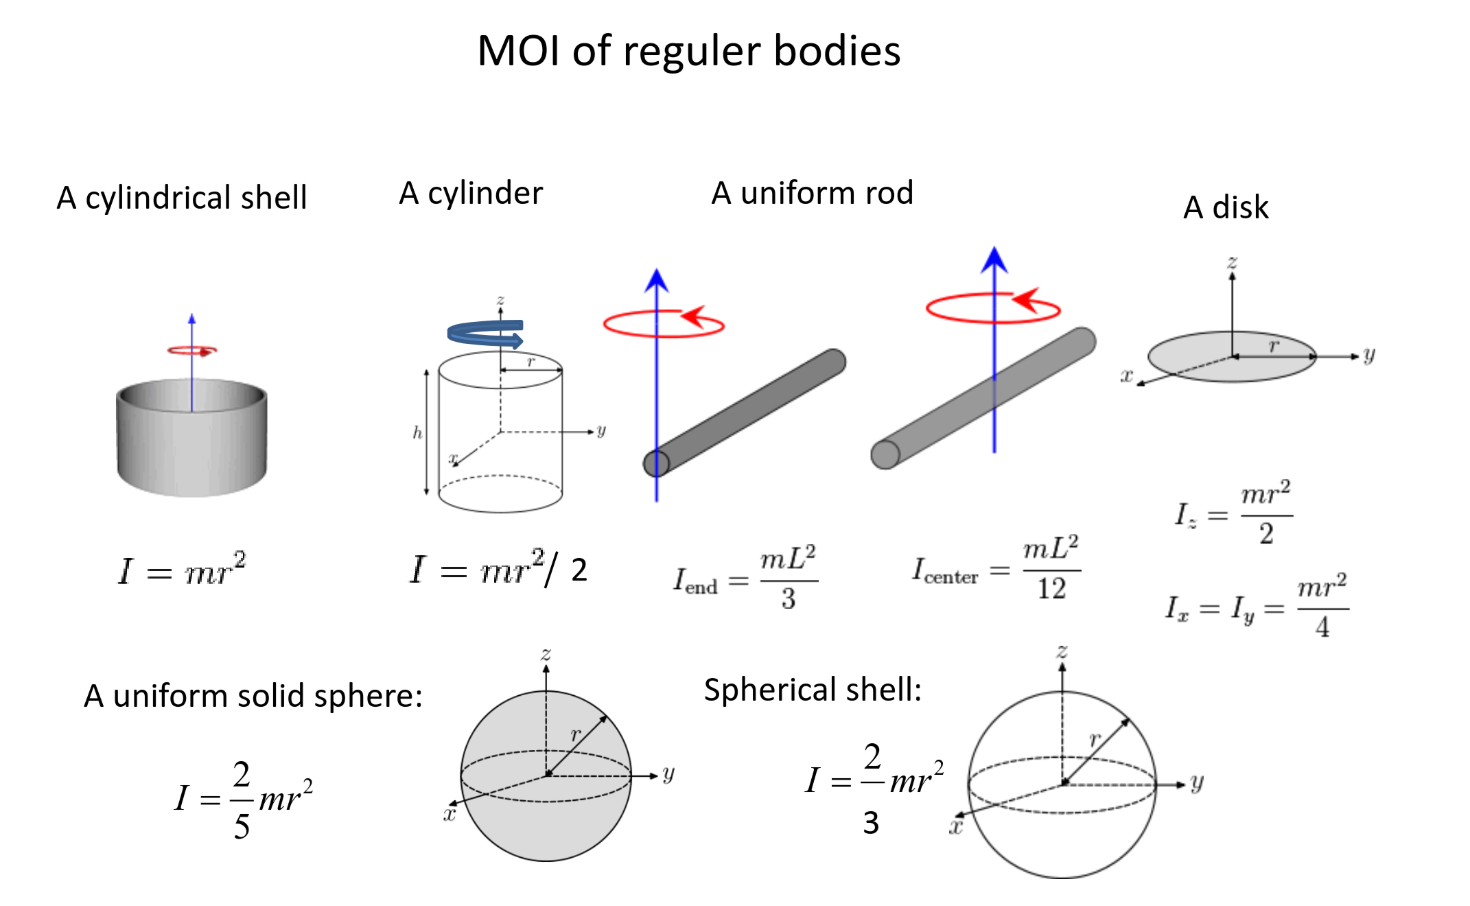

In [6]:

from opg2 import moment_of_inertia_rod_com

mass = 2  # kg
I_c = moment_of_inertia_rod_com(mass, L[0])
print("Moment of Inertia of link OA about CoM:")
print(I_c)

Moment of Inertia of link OA about CoM:
0.041666666666666664


#### 3) 
Free body diagram for R robot
![image.png](./../image%20copy%202.png)

#### 4)

Vi bruger newtons anden lov for translation og rotation:

$$
\sum \vec{F} = m\vec{a_{c}}
$$
$$
\sum \vec{M_{c}} = I_{c}\dot{\omega}
$$

Dette giver os følgende ligninger:
Translation:
$$
\vec{F}_{0,1}+\vec{F}+m\vec{g} = m\vec{\dot{v}_{c}}
$$
Rotation
$$
\tau + (-s_c) \underline{\times} \vec{F}_{0,1} + (s_1-s_c)\underline{\times}\vec{F}  = I_c \dot{\omega}
$$

#### 5)

Det gøres ved først at isolere for $\vec{F}_{0,1}$ i translations ligningen, og indsætte denne i rotations ligningen. For herefter isoleres for $\tau$.

$$
\vec{F}_{0,1} = m\vec{\dot{v}_{c}} - \vec{F} - m\vec{g}
$$

$$
\tau = I_c \dot{\omega} - (-s_c) \underline{\times} \vec{F}_{0,1} -(s_1-s_c)\underline{\times}\vec{F}
$$
$$
= I_c \dot{\omega} - (-s_c) \underline{\times} (m\vec{\dot{v}_{c}} - \vec{F} - m\vec{g}) - (s_1-s_c)\underline{\times}\vec{F}
$$
Substituerer vi de giver værdiger ind og ud regner får vi: 


In [7]:
from opg2 import s_vec

ang_acc = aa_list[0].subs(t, solve_t).evalf()
trans_acc = com_acc_list[0].subs(t, solve_t).evalf()

s_c1 = s_vec(theta_list[0].subs(t, solve_t), L[0]/2)
s_1 = s_vec(theta_list[0].subs(t, solve_t), L[0])

z = sp.Matrix([0,0,1])

F = sp.Matrix([5,-2,0])


F_0_1 = mass*trans_acc - F - mass*9.81*sp.Matrix([0,-1,0])


tau = I_c * ang_acc - ((-s_c1).cross(F_0_1))[2] - (s_1 - s_c1).cross(F)[2]

print("Required Torque at OA:")
print(tau.evalf())




Required Torque at OA:
-6.31631908576906
